<a href="https://colab.research.google.com/github/JBlankenship1/MachineLearningProjects/blob/main/PCA-NN-Bagging-DigitIdentifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 460G: Machine Learning
## Spring 2026
## Assignment 3

___


Name: Jacob Blankenship

ID: 912676349

Email: jrblanke2@gmail.com

# READ THIS FIRST

## Reminder on what's up for you in this assignment

This is one of the four assignments. A maximum of 100 points are available from this assignment. You will need to use your learning from the Neural Network and Ensemble Learning lectures.

You will turn in completed version of this notebook (both ipynb and pdf files). Your submission will be graded under 3 major factors:

  * Functional code: Completed code with every piece functional
  * Correctness: Your submitted notebook contains correct code that gives accurate results unless otherwise stated
  * Documentation: Every cell is well-documented and easy-to-follow to reproduce the results

$~$

## Reproducibility in iPython Notebooks

As you have noticed, iPython notebooks are interactive Python sessions that allow us to spread our code, text, and markdown seamlessly.

Every word you read and write is modifiable. You can double click this cell to change the text you're reading now. You will use such cells to write your answers/code.

Don't forget to double click the first cell, and write your name, ID, and email.

Cells can be added for code or text. Check the top left corner: "+Code" to add a new cell for writing code and "+Text" to add a new cell for raw texts.

The best thing about notebooks is that you can quickly run small components of your code in separate cell to make sure they work before putting together for a larger component. Another good thing is, as you noticed during our in-class hands-on, the entire assignment self-contained in this ipynb file. So, you can put all your functions and classes into the cells of this notebook. Please make sure your code is written cleanly with documentation (how to use your work once completed, to reproduce the exact same results). Particularly, pay attention to setting random_state (where applicable) to ensure reproducibility of your results. Once you're done, download the notebook as ipynb file and submit on Canvas before the due date. Please also make sure to download the PDF file when everything works fine: File-->Print-->Save as PDF

Please be reminded, it is important to write readable and reproducible code. Let's take a small fine step towards that goal, with this notebook.

## **Digit Image Classification using Neural Netorks**

---

This assignment is focused on three objectives:
  1. Perform PCA to reduce data dimensionality and select top k most relevant features
  2. Design and implement a Multi-Layer Perceptron Neural Network to perform digit image classification
  3. Perform an ensemble learning (Bagging-->majority voting) to improve the model performance

# Dataset Exploration and PCA for Feature Selection (30 points)

### First we load the dataset and explore it. Since the dataset already available on PyTorch, google drive mounting is not required.   

#### To Do:

 * Load the MNIST digit image datasets from PyTorch using the following line
      `trainset = torchvision.datasets.MNIST(root = "./data", train = True, download=True)`     
      
      - For loading test set, just set `train=False`

In [77]:
import torch
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.neural_network import MLPClassifier
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torchsummary import summary
import torch.nn.functional as F


#### Read the data

---


#### Understand it: check, analyze, visualize

#### Train data

In [78]:
'''Train data from the MNIST dataset'''
trainset = datasets.MNIST('./data', train=True, download=True)
classes = ('0', '1', '2', '3', '4', '5',
           '6', '7', '8', '9')

In [79]:
'''Initialize an empty list for images and another one for labels'''
X_train = []
Y_train = []

'''Get the training images and their corresponding labels'''
for k, (image, label) in enumerate(trainset):
    X_train.append(image)
    Y_train.append(label)

'''reshape image and label arrays'''
X_train = np.reshape(X_train, [-1, 28*28])
Y_train = np.reshape(Y_train, [-1])

'''Verify shape: (60000, 784) and (60000,)'''
X_train.shape, Y_train.shape

((60000, 784), (60000,))

#### Visualize one train image from each class in subplots
    - The subplots are in a single row
    - Print the class labels as the title of each subplot
    - The images should be shown using 'gray' color map

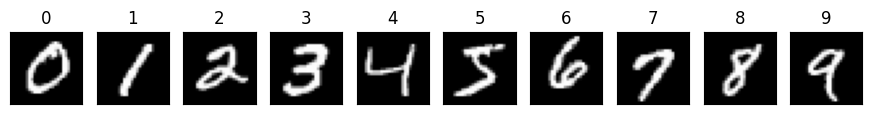

In [80]:
'''Visualize the digit images in a single row'''

digitnum = 0
digitarr = []
for i in range(0,10):
  digitarr.append(np.where(Y_train == i)[0][0])
#https://stackoverflow.com/questions/18079029/index-of-element-in-numpy-array#18079151

fig = plt.figure(figsize=(11, 1))
for k in range(len(digitarr)):
  temparr = X_train[digitarr[k]].reshape(28,28)
  fig.add_subplot(1,10,k+1)
  plt.title('%i' %Y_train[digitarr[k]])
  plt.xticks(())
  plt.yticks(())
  plt.imshow(temparr,cmap='gray', vmin=0, vmax=255)
plt.show()


#### Load Test data

Now, repeat the above steps to load the testset, create X_test and y_test arrays, and visualize 10 gray colormap digit images in a single row

In [81]:
'''load test data'''
testset = datasets.MNIST('./data', train=False, download=True)

In [82]:
'''Initialize an empty list for images and another one for labels'''
images = []
labels = []

'''Get the testing images and their corresponding labels'''
X_test = []
Y_test = []

for k, (image, label) in enumerate(testset):
    X_test.append(image)
    Y_test.append(label)

'''reshape image and label arrays'''
X_test = np.reshape(X_test, [-1, 28*28])
Y_test = np.reshape(Y_test, [-1])

'''Verify shape: (10000, 784) and (10000,)'''
X_test.shape, Y_test.shape

((10000, 784), (10000,))

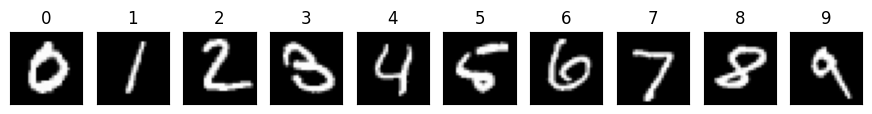

In [83]:
'''Visualize the digit images of 10 classes in a single row'''

digitnum = 0
digitarr = []
for i in range(0,10):
  digitarr.append(np.where(Y_test == i)[0][0])
#https://stackoverflow.com/questions/18079029/index-of-element-in-numpy-array#18079151

fig = plt.figure(figsize=(11, 1))
for k in range(len(digitarr)):
  temparr = X_test[digitarr[k]].reshape(28,28)
  fig.add_subplot(1,10,k+1)
  plt.title('%i' %Y_test[digitarr[k]])
  plt.xticks(())
  plt.yticks(())
  plt.imshow(temparr,cmap='gray', vmin=0, vmax=255)
plt.show()

### Perform PCA: Select top k features

- Use only the numpy package
- Find the top k principal components that can explain at least 90% variance
- Visualize the top k principal components cumulative percentage of explained variance

In [84]:
'''First standardize the data: normalize to 0-1'''
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

diff = X_max - X_min

safe_diff = np.where(diff != 0, diff, 1)

X_train_scaled = np.where(diff != 0, (X_train - X_min) / safe_diff, 0)

X_train_scaled, X_train, X_train_scaled.shape

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 (60000, 784))

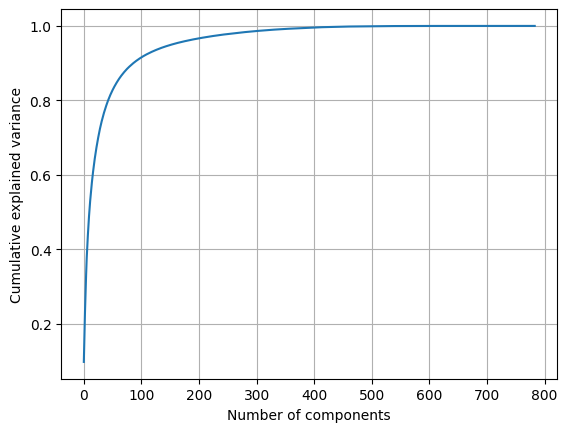

In [85]:
'''Principal Components using numpy'''
cov = np.cov(X_train_scaled.T)
eval, evec = np.linalg.eig(cov)
eval_rat = [i/eval.sum() for i in eval]
plt.plot(np.cumsum(eval_rat))
plt.grid()
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance');


87


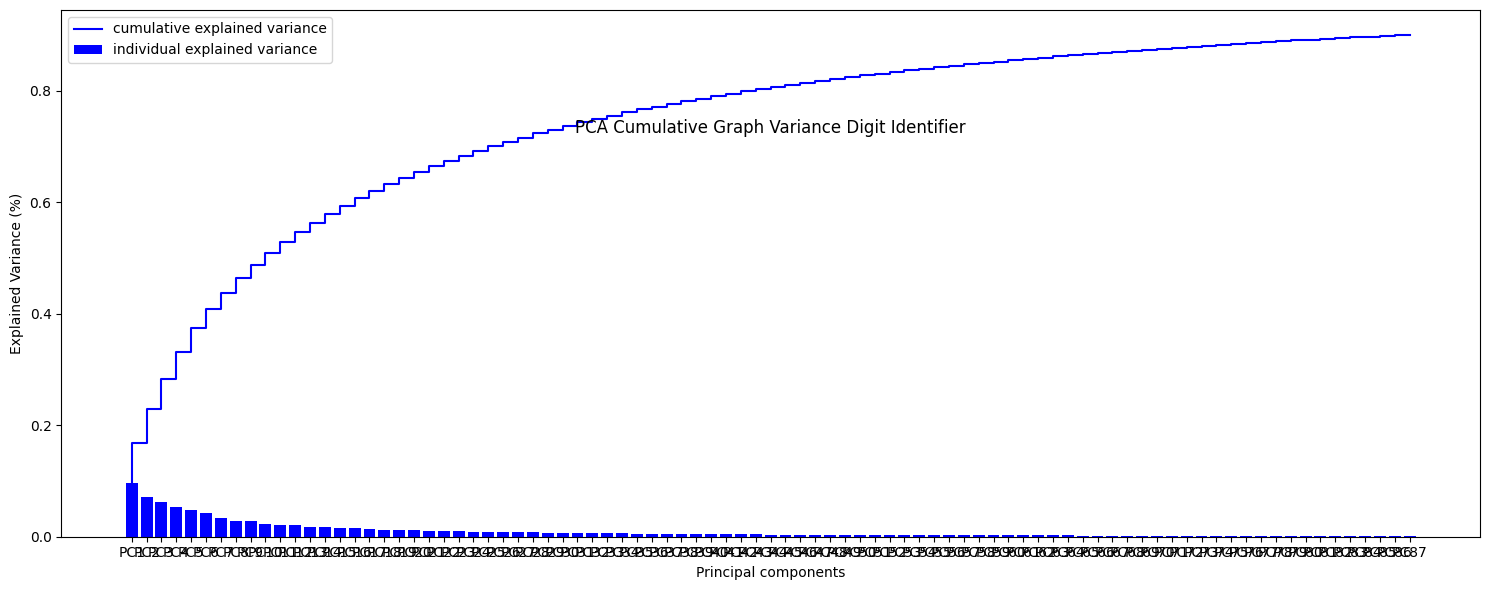

In [86]:
'''Plot the top k principal components explaining >90% variance'''
cum_var = np.cumsum(eval_rat)

nstep = 0
for n in range(len(cum_var)):
    if cum_var[n] >= 0.9:
        nstep = n + 1
        break
print(nstep)

plt.figure(figsize=(15, 6))

indiv_var = eval_rat[:nstep]
#https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html
cumul_var = cum_var[:nstep]

plt.bar(range(1, nstep + 1), indiv_var, color='b', align='center',
        label='individual explained variance')

plt.step(range(1, nstep + 1), cumul_var, color='b',
         label='cumulative explained variance')

plt.xticks(range(1, nstep + 1),
           ['PC' + str(i) for i in range(1, nstep + 1)])
plt.xlabel('Principal components')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Cumulative Graph Variance Digit Identifier', y=0.75)
plt.legend(loc='best')
plt.tight_layout();

In [87]:
'''Sort the eigen values in descending order and the corresponding eigen vectors'''
sorted_idx = np.argsort(eval)[::-1]
eval = eval[sorted_idx]
evec = evec[:, sorted_idx]

In [88]:
'''Select the top k PCs, perform reshape as you might find it necessary'''
eval_rat = eval / eval.sum()
cum_var = np.cumsum(eval_rat)
nstep = 0
for n in range(len(cum_var)):
    if cum_var[n] >= 0.9:
        nstep = n + 1
        break

top_evec = evec[:, :nstep]
#https://numpy.org/doc/stable/reference/generated/numpy.matmul.html
PCA_train_x = np.matmul(X_train_scaled,top_evec).real
PCA_train_x.shape, PCA_train_x

((60000, 87),
 array([[-3.45384869, -1.29392487,  0.77492614, ...,  0.1353437 ,
          0.04084173, -0.64363903],
        [-6.93536157, -1.22405327,  3.2096462 , ...,  0.14636798,
         -0.16410205, -0.11774294],
        [-2.7645068 ,  1.47018283,  0.13180633, ..., -0.14965935,
         -0.13197264,  0.08072987],
        ...,
        [-2.2695897 ,  0.56000644, -0.13918759, ...,  0.00851198,
          0.42057164, -0.52762102],
        [-3.48001929, -0.0896803 ,  2.88619232, ...,  0.24853793,
         -0.29677023,  0.22319681],
        [-2.28769757, -0.16468765,  3.05152615, ..., -0.31242917,
         -0.23465764, -0.24138078]]))

### PCA on Test data
Now, repeat the above steps to perform feature selection on the test data

In [89]:
'''Select the top k PCs, perform reshape as you might find it necessary'''

X_test_scaled = np.where(diff != 0, (X_test - X_min) / safe_diff, 0)
PCA_test_x = np.matmul(X_test_scaled, top_evec).real # Using same eigenvectors made before to not train PCA on test data
PCA_test_x.shape, PCA_test_x

((10000, 87),
 array([[-1.66481437e+00,  2.86479278e+00,  7.03040917e-01, ...,
          3.67444097e-01,  2.77091577e-02, -9.76230955e-02],
        [-3.04900310e+00, -3.81514205e+00,  2.72176024e-01, ...,
         -3.07155190e-01, -5.49489209e-01, -2.40468878e-01],
        [ 7.42070677e-01, -1.75733215e+00,  1.13057516e+00, ...,
         -6.48157713e-02, -5.18147998e-02, -2.07607554e-01],
        ...,
        [-1.90827875e+00,  2.27291562e+00,  2.26365069e+00, ...,
          3.48781356e-01, -3.93361010e-01, -1.75699148e-01],
        [-1.73635876e+00, -4.93646693e-01,  3.39200297e+00, ...,
          2.55512688e-01,  1.03231477e-01,  2.77331245e-02],
        [-7.05563984e+00, -4.22710844e-01,  3.64015476e+00, ...,
          8.19604917e-02, -1.22095419e-04, -2.58977028e-01]]))

# Build a Neural Network model for digit image classification (30 points)

### Set up a Multilayer Perceptron Neural Net

First create a PyTorch dataloader using a batchsize of 64

In [90]:
from torch.utils.data import TensorDataset, DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 64

# Convert to tensor
X_train_tensor = torch.tensor(PCA_train_x, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)

X_test_tensor = torch.tensor(PCA_test_x, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)


In [91]:
'''Now create train and test dataloader'''

# group images+labels in DataLoader
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

### Now, define a Neural Network (MLP) following this specification:
  - 3 layer network
  - 2 hidden layers are of 50 and 20 neurons, respectively
  - activation functions are: lrelu, lrelu, and softmax
  - loss function: Cross-entropy loss
  - optimizer: Adam optimizer with learning rate of 1e-4


In [92]:
'''Define MLP network'''
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(87, 50) # 87 PCA attributes -> 50 neurons
        self.fc2 = nn.Linear(50, 20) # 50 neurons -> 20 neurons
        self.fc3 = nn.Linear(20, 10) # 20 neurons -> 10 classes

    def forward(self, x):
        x = x.view(-1, 87)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Told to define loss function after initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

net = Net()
net = net.to(device)


In [93]:
'''Print the model architecture'''
print(net)

Net(
  (fc1): Linear(in_features=87, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=10, bias=True)
)


In [94]:
'''Summarize the architecture and model parameters'''
from torchsummary import summary

summary(net, (87,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]           4,400
            Linear-2                   [-1, 20]           1,020
            Linear-3                   [-1, 10]             210
Total params: 5,630
Trainable params: 5,630
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


In [95]:
'''Define Loss function criterion'''
criterion = nn.CrossEntropyLoss()

In [96]:
'''Set the learning rate and define the optimizer'''
lr = 0.0001
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

In [97]:
'''Run the training for 50 epochs, print loss in every epoch'''
for epoch in range(50):  # loop over the dataset multiple times

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data
        inputs = inputs.to(device).float()
        labels = labels.to(device).long()

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    # Print Loss every epoch
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader):.4f}")

print('Finished Training')

Epoch 1, Loss: 1.7964
Epoch 2, Loss: 0.7663
Epoch 3, Loss: 0.4959
Epoch 4, Loss: 0.4007
Epoch 5, Loss: 0.3544
Epoch 6, Loss: 0.3271
Epoch 7, Loss: 0.3086
Epoch 8, Loss: 0.2941
Epoch 9, Loss: 0.2827
Epoch 10, Loss: 0.2717
Epoch 11, Loss: 0.2617
Epoch 12, Loss: 0.2531
Epoch 13, Loss: 0.2445
Epoch 14, Loss: 0.2366
Epoch 15, Loss: 0.2288
Epoch 16, Loss: 0.2216
Epoch 17, Loss: 0.2146
Epoch 18, Loss: 0.2081
Epoch 19, Loss: 0.2018
Epoch 20, Loss: 0.1960
Epoch 21, Loss: 0.1904
Epoch 22, Loss: 0.1851
Epoch 23, Loss: 0.1800
Epoch 24, Loss: 0.1753
Epoch 25, Loss: 0.1710
Epoch 26, Loss: 0.1666
Epoch 27, Loss: 0.1626
Epoch 28, Loss: 0.1588
Epoch 29, Loss: 0.1552
Epoch 30, Loss: 0.1518
Epoch 31, Loss: 0.1485
Epoch 32, Loss: 0.1453
Epoch 33, Loss: 0.1426
Epoch 34, Loss: 0.1396
Epoch 35, Loss: 0.1369
Epoch 36, Loss: 0.1344
Epoch 37, Loss: 0.1319
Epoch 38, Loss: 0.1295
Epoch 39, Loss: 0.1274
Epoch 40, Loss: 0.1251
Epoch 41, Loss: 0.1231
Epoch 42, Loss: 0.1211
Epoch 43, Loss: 0.1192
Epoch 44, Loss: 0.11

In [98]:
'''Perform testing on the entire test set'''
#get a test batch
dataiter = iter(testloader)
images, labels = next(dataiter)

images = images.to(device).float()
labels = labels.to(device).long()

#make the prediction from the trained model
outputs = net(images)

labels, outputs

(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
         4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
         4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0'),
 tensor([[-3.6480e+00, -5.8452e+00, -8.3657e-01,  9.9382e-01, -8.9510e+00,
          -5.2652e+00, -1.1374e+01,  8.7741e+00, -4.9818e+00, -3.9058e+00],
         [-1.0808e+00, -9.1454e-01,  7.9319e+00,  1.1015e+00, -1.7210e+01,
          -1.2359e+00, -1.3050e+00, -1.3498e+01, -2.0890e-02, -1.4352e+01],
         [-6.4082e+00,  5.0135e+00, -6.1157e-01, -2.6636e+00, -4.6169e+00,
          -5.3939e+00, -1.7206e+00, -4.6524e-01, -7.4429e-01, -6.3015e+00],
         [ 9.8215e+00, -7.9760e+00, -3.9603e+00, -5.3954e+00, -1.0970e+01,
          -4.3492e+00, -1.3136e+00,  1.5710e-01, -6.8657e+00, -6.6853e+00],
         [-5.4871e+00, -9.2698e+00, -2.5704e+00, -2.7714e+00,  5.9069e+00,
          -2.9120e+00, -1.8016e+00, -1.1775e+00, -2.0250e+00,  1.3649e+00],
       

In [99]:
#test on the whole test set
correct = 0
total = 0
y_test = np.zeros((0))
y_pred = np.zeros((0))

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device).float()
        labels = labels.to(device).long()

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        y_test = np.concatenate([y_test, labels.cpu()])
        y_pred = np.concatenate([y_pred, predicted.cpu()])

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %.2f %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 96.48 %


# Ensemble learning $-$ Bagging (30 points)

## Perform Bagging by training the same MLP on 3 different subsets and make the final prediction through a majority voting

Add below new cells as you need to perform the bagging. Do not add all the codes in a single cell.

In [100]:
X_sub = []
Y_sub = []
models = []

for split in range(3):
    n = len(PCA_train_x)
    size = int(0.8 * n)  # Hyperparameter
    # https://www.baeldung.com/cs/bagging-boosting-stacking-ml-ensemble-models
    # Used the site above for reference on hyperparameter and bagging sampling structure
    indices = np.random.choice(n, size, replace=False)

    X_sub = PCA_train_x[indices]
    Y_sub = Y_train[indices]

    X_sub_tensor = torch.tensor(X_sub, dtype=torch.float32)
    Y_sub_tensor = torch.tensor(Y_sub, dtype=torch.long)

    sub_dataset = TensorDataset(X_sub_tensor, Y_sub_tensor)
    subsetloader = DataLoader(sub_dataset, batch_size=64, shuffle=True)
    subset_model = Net().to(device)
    optimizer = torch.optim.Adam(subset_model.parameters(), lr=lr)
    # Redefining optimizer, kept learning rate the same

    for epoch in range(50):
        # Training in same chunk to not have to append everything to arrays
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(subsetloader, 0):
            # get the inputs
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = subset_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

        print(f'[Epoch {epoch + 1}, Model {split}] loss: {running_loss / len(subsetloader):.3f}')
    # Appends model for test
    models.append(subset_model)

print('Finished Training')


len(X_sub), X_sub[0].shape, X_sub[1].shape, X_sub[2].shape

[Epoch 1, Model 0] loss: 1.958
[Epoch 2, Model 0] loss: 0.929
[Epoch 3, Model 0] loss: 0.551
[Epoch 4, Model 0] loss: 0.445
[Epoch 5, Model 0] loss: 0.395
[Epoch 6, Model 0] loss: 0.364
[Epoch 7, Model 0] loss: 0.342
[Epoch 8, Model 0] loss: 0.326
[Epoch 9, Model 0] loss: 0.312
[Epoch 10, Model 0] loss: 0.301
[Epoch 11, Model 0] loss: 0.291
[Epoch 12, Model 0] loss: 0.282
[Epoch 13, Model 0] loss: 0.274
[Epoch 14, Model 0] loss: 0.267
[Epoch 15, Model 0] loss: 0.260
[Epoch 16, Model 0] loss: 0.253
[Epoch 17, Model 0] loss: 0.247
[Epoch 18, Model 0] loss: 0.241
[Epoch 19, Model 0] loss: 0.236
[Epoch 20, Model 0] loss: 0.231
[Epoch 21, Model 0] loss: 0.226
[Epoch 22, Model 0] loss: 0.221
[Epoch 23, Model 0] loss: 0.216
[Epoch 24, Model 0] loss: 0.212
[Epoch 25, Model 0] loss: 0.207
[Epoch 26, Model 0] loss: 0.203
[Epoch 27, Model 0] loss: 0.199
[Epoch 28, Model 0] loss: 0.195
[Epoch 29, Model 0] loss: 0.191
[Epoch 30, Model 0] loss: 0.188
[Epoch 31, Model 0] loss: 0.184
[Epoch 32, Model 

(48000, (87,), (87,), (87,))

In [101]:
all_preds = []

for model in models:
    model.eval()
    preds = []

    with torch.no_grad():
        for inputs, _ in testloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())

    all_preds.append(preds)

# shape: (3 models, num_samples), should be a tuple?
all_preds = np.array(all_preds)
for i, preds in enumerate(all_preds):
    print(f"Model {i+1} first 10 predictions: {preds[:10]}")

# Subset to check if models are converging
print(f"\nPer-sample predictions (first 5 samples):")
print(all_preds[:, :5])



Model 1 first 10 predictions: [7 2 1 0 4 1 4 9 6 9]
Model 2 first 10 predictions: [7 2 1 0 4 1 4 9 5 9]
Model 3 first 10 predictions: [7 2 1 0 4 1 4 9 6 9]

Per-sample predictions (first 5 samples):
[[7 2 1 0 4]
 [7 2 1 0 4]
 [7 2 1 0 4]]


In [102]:
from scipy import stats
# https://docs.scipy.org/doc/scipy/reference/stats.html
# I want the mode in plurality voting, scipy can give mode of my tupleset
true_labels = []

ensemble_preds, _ = stats.mode(all_preds, axis=0)
ensemble_preds = ensemble_preds.flatten()

# Get labels from testloader
for _, labels in testloader:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# Accuracy in bagging subsets
for i, preds in enumerate(all_preds):
    acc = np.mean(preds == true_labels) * 100
    print(f"Model {i+1} Accuracy: {acc:.2f}%")

all_ensemble_acc = np.mean(ensemble_preds == true_labels) * 100
print(f"\nEnsemble Accuracy (majority vote): {all_ensemble_acc:.2f}%")


Model 1 Accuracy: 95.61%
Model 2 Accuracy: 95.84%
Model 3 Accuracy: 95.89%

Ensemble Accuracy (majority vote): 96.05%


# Final Discussion (5 points)

**Based on your experiments above, discuss your findings comparing the approaches having PCA-based preprocessing and ensemble learning. Also add if you faced any challenges while working on this assignment.**

Initially when running bagging, I only did 20 epochs for each subset. This gave an accuracy of only ~94%, which is less than the initial implmentation of ~96%. However, when reran with the same epochs as the non-bagging method, the accuracy shot up to 96%. Meaning that, overall, PCA-based preprocessing alone performed the same as an ensemble learning implementation. This surprises me, but makes sense if my neuron structure and optimizer paramaters converge at around 96%.

An initial issue with PCA was that my reference (assignment #2), hasn't been graded yet. This makes it hard to see the performance of my PCA and how correct it was. Another challenge was the ensemble voting, as the collab workbook wasn't applicable to this assignment ("Ensemble-Methods.ipynb"). Thankfully I am now connected to the A100 gpus making running large epochs in training much easier.

# Use of Generative AI (5 points)

**1. Did you get any help from any Generative AI tools (e.g., ChatGPT) for completing this assignment task? Please explain.** (1 points)

Your response:


$~$ I did not use generative AI in this assignment. Similar to the last assignment, I turned off the AI assistant in the assignment and only used online resources such as geeksforgeeks and package support pages. Some of these packages are cited in my work, but other sites used were not cited. There was a site with actual python code listed for the bagging implementation that I referenced in my code, but did not copy and paste.


**2. What prompts did you use to get assistance from Generative AI? Please list all the prompts that you used.
If you didn't get any Generative AI assistance, simply write the following text to respond this question.** (3 points)
> **I didn't seek any Generative AI assistance to complete this assignment task.**

Your reponse:


$~$ I didn't seek any Generative AI assistance to complete this assignment task.


**3. How would you distribute credit between you and the Generative AI tool? Please give the percentage of your contribution and the contribution of Generative AI.** (1 points)

Your reponse: 100% myself, 0% AI.

# Discussion with others in the class (Bonus 5 points)

**Discuss what level of discussion you have had with anyone else in the class? Mention the name and what did you discuss**

I discussed the assginment with Karoline Leech, but in the context of implementing a similar method in our leaf identifier project. We also discussed in general terms how difficult the assignment was.